<center><b>EE (P) 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>


<b>Instructor: Mahmood Hameed<br>
Assignment #1 (10 points)<br>
Due Monday, April 13 (Submit on Canvas as a Jupyter Notebook)</b> 

<b>Problem 1: Sensor interfaces, loading, frequency response

<img src="HW1_Fig1.png" width="400">

Photodiodes, which are used to convert light into electric current, are typically modeled as shown above, as current sources in parallel with a "small-signal" resistance and a junction capacitance. The resistance and capacitance exhibited by the diode are in general nonlinear, such that the linear approximations shown here are valid only over a narrow range of currents/voltages. For the purposes of analysis and design, we treat them as simple passive components $r_d$ and $c_j$.

<u>*Analysis*</u>

__a)__ Determine an expression for the the transfer function $\dfrac{V_{in}}{I_d}(s)$ in terms of $r_d$, $c_j$, and $R_{in}$.

$r_d$, $c_j$ and $R_{in}$ are all in parallel between $v_{in}$ and ground, so $i_d$ sees their parallel impedance. Let $R_p = r_d \| R_{in} = \dfrac{r_d R_{in}}{r_d + R_{in}}$. Then

$$
\frac{V_{in}}{I_d}(s) \;=\; R_p \;\Big\|\; \frac{1}{s c_j} \;=\; \frac{R_p}{1 + s R_p c_j}.
$$

__b)__ Let $r_d = 10k\Omega$, $c_j = 1pF$, and $R_{in} = 1k\Omega$. Use *Python* to plot the magnitude and phase of the transfer function $\dfrac{V_{in}}{I_d}(s)$. What is the 3db-bandwidth ($\omega_0 = 1/\tau$) of the magnitude response?  

Plug in the numbers:

$$
R_p = \frac{(10\text{k})(1\text{k})}{11\text{k}} \approx 909.09\,\Omega, \qquad \tau = R_p c_j \approx 909\,\text{ps},
$$

$$
\omega_0 = \frac{1}{\tau} \approx 1.10 \times 10^{9}\;\text{rad/s}, \qquad f_0 = \frac{\omega_0}{2\pi} \approx 175.1\;\text{MHz}.
$$

R_p=909.0909090909091
tau=9.090909090909091e-10
w0=1100000000.0
f0=175070437.40108487


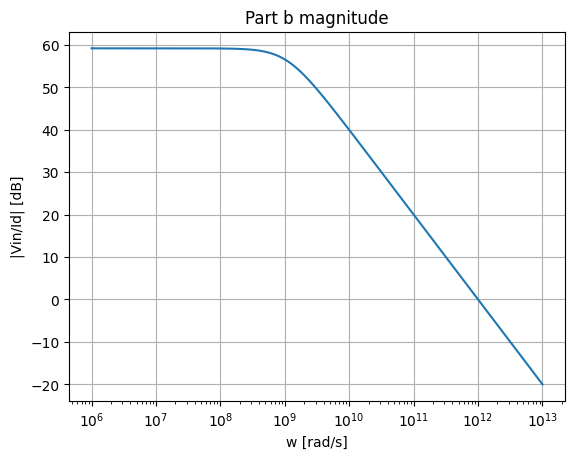

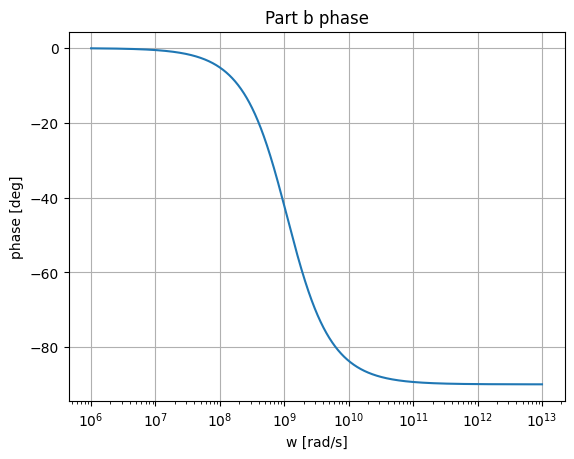

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r_d=10e3
c_j=1e-12
R_in=1e3

R_p=(r_d*R_in)/(r_d+R_in)
tau=R_p*c_j
w0=1/tau
f0=w0/(2*np.pi)

print(f'R_p={R_p}')
print(f'tau={tau}')
print(f'w0={w0}')
print(f'f0={f0}')

w=np.logspace(6,13,2001)
H=R_p/(1+1j*w*R_p*c_j)
mag=20*np.log10(np.abs(H))
phase=np.angle(H,deg=True)

plt.figure()
plt.semilogx(w,mag)
plt.xlabel('w [rad/s]')
plt.ylabel('|Vin/Id| [dB]')
plt.title('Part b magnitude')
plt.grid(True)
plt.show()

plt.figure()
plt.semilogx(w,phase)
plt.xlabel('w [rad/s]')
plt.ylabel('phase [deg]')
plt.title('Part b phase')
plt.grid(True)
plt.show()

From the printout, the 3 dB bandwidth is $\omega_0 \approx 1.10\times 10^{9}$ rad/s, i.e. $f_0 \approx 175$ MHz.

*Please show your work*

<u>*Design*</u>

__c)__ For the values of $r_d$ and $R_{in}$ in *Part b*, by what percentage is the diode current attenuated due to loading at DC ($f = 0$)? That is, what percentage of $i_d$ is "lost" due to the finite output resistance ($r_d$) of the diode? 

Calculate a new value of $R_{in}$ that results in only 0.1% attenuation of the diode current at DC.

*Note: For DC calculations you can ignore the presence of $c_j$, because its impedance magnitude $\left|\frac{1}{j\omega c_j}\right|$ is infinite.*

At DC $c_j$ is open, so $i_d$ splits between $r_d$ and $R_{in}$ as a current divider. The current that reaches $R_{in}$ is

$$
i_{in} = i_d \cdot \frac{r_d}{r_d + R_{in}},
$$

and the fraction lost through $r_d$ is

$$
\text{attenuation} = \frac{R_{in}}{r_d + R_{in}}.
$$

With $r_d = 10\text{k}\Omega$ and $R_{in} = 1\text{k}\Omega$, this gives $1/11 \approx 9.09\%$.

For 0.1% attenuation:

$$
\frac{R_{in}}{r_d + R_{in}} = 0.001 \;\Rightarrow\; R_{in} = \frac{0.001\,r_d}{0.999} \approx 10.01\,\Omega.
$$

In [2]:
r_d=10e3
R_in=1e3

atten=R_in/(r_d+R_in)
print(f'old attenuation={atten*100}%')

target=0.001
R_in_new=target*r_d/(1-target)
print(f'new R_in={R_in_new}')

check=R_in_new/(r_d+R_in_new)
print(f'check={check*100}%')

old attenuation=9.090909090909092%
new R_in=10.01001001001001
check=0.1%


__d)__ Using the value of $R_{in}$ calculated in *Part c*, use *Python* to plot the magnitude and phase of the transfer function. Build the circuit in SPICE and run an AC simulation. Ensure that the magnitude/phase responses agree with those from your analytical (*Python*) model.

R_p=9.99999000999999
tau=9.99999000999999e-12
w0=100000099900.0999
f0=15915510208.784248


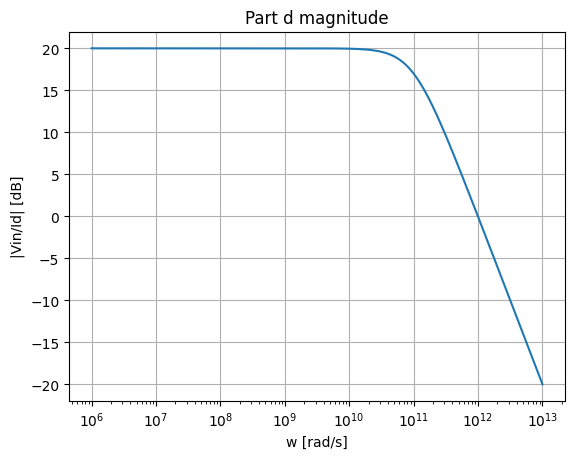

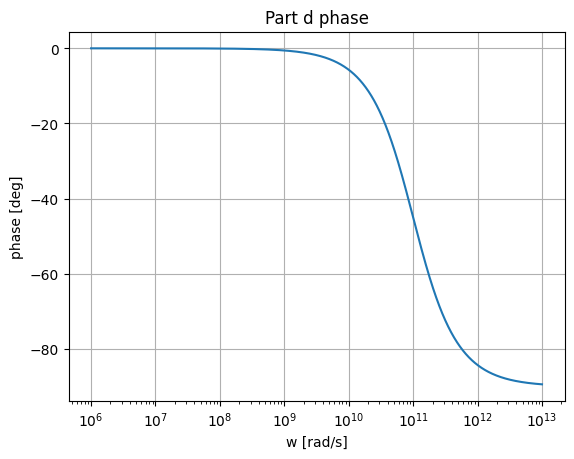

In [3]:
r_d=10e3
c_j=1e-12
R_in=10.01

R_p=(r_d*R_in)/(r_d+R_in)
tau=R_p*c_j
w0=1/tau
f0=w0/(2*np.pi)

print(f'R_p={R_p}')
print(f'tau={tau}')
print(f'w0={w0}')
print(f'f0={f0}')

w=np.logspace(6,13,2001)
H=R_p/(1+1j*w*R_p*c_j)
mag=20*np.log10(np.abs(H))
phase=np.angle(H,deg=True)

plt.figure()
plt.semilogx(w,mag)
plt.xlabel('w [rad/s]')
plt.ylabel('|Vin/Id| [dB]')
plt.title('Part d magnitude')
plt.grid(True)
plt.show()

plt.figure()
plt.semilogx(w,phase)
plt.xlabel('w [rad/s]')
plt.ylabel('phase [deg]')
plt.title('Part d phase')
plt.grid(True)
plt.show()

With $R_{in} \approx 10.01\,\Omega$, $R_p \approx 10\,\Omega$, $\tau \approx 10\,\text{ps}$, $\omega_0 \approx 1.0\times 10^{11}$ rad/s, $f_0 \approx 15.9$ GHz.

So the DC gain dropped from about 909 $\Omega$ to about 10 $\Omega$, but the bandwidth went from about 175 MHz up to about 15.9 GHz. Smaller $R_{in}$ means almost no current is lost in $r_d$, but the output voltage swing also gets smaller. Classic gain vs bandwidth tradeoff.

**SPICE check (LTspice).** Netlist [photodiode.cir](photodiode.cir): `I1 0 vin AC 1`, `Rd vin 0 10k`, `Cj vin 0 1p`, `Rin vin 0 10.01`, `.ac dec 100 1Meg 100G`.

<img src="d.png" width="700">

The DC plateau sits at about 20 dB, the corner is near 16 GHz, and the phase rolls from 0° toward -90°. This matches the Python plot above.

<br><br>*Suggestion: Try using Latex for displaying mathematical expressions and equations. One nice feature of Jupyter Notebooks is its ability to incorporate both code and "markup," used for formatting text, into the same document. Some examples of Latex are given above in the problem descriptions. You can press Return or double click a cell to see the markup, then use Shift-Return to view the formatted version. Here are a few more examples:*

\begin{equation}
j = \sqrt{-1} \\
V = IR \\
I_C = C \cdot \frac{dV}{dt} 
\end{equation}